# Task 1 — Dynamic Engagement Score

Run the setup cell, then run the final cell. Produces weekly engagement scores, validation tables, four report archetypes, and 4-cluster analysis.


In [1]:
%matplotlib inline


## Setup

This defines all functions. It may look long, but you only need to run it once.

In [2]:

"""
Task 1 Version 2: Dynamic Behavioural Engagement Score for OULAD

How to use:
1. Put this file in the same folder as your datasets/ folder.
2. Make sure datasets/ contains:
   studentInfo.csv, studentVle.csv, vle.csv, studentAssessment.csv, assessments.csv
3. Run:
   python task1_engagement_v2.py

Outputs:
- engagement_scores_v2.csv
- archetype_trajectories_v2.png
- cluster_trajectories_v2.png
- cluster_profiles_v2.csv
- validation_v2.csv
"""

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from sklearn.cluster import KMeans
    from sklearn.preprocessing import StandardScaler
    from sklearn.metrics import roc_auc_score
    SKLEARN_AVAILABLE = True
except Exception:
    SKLEARN_AVAILABLE = False


# ---------------------------------------------------------------------
# User settings
# ---------------------------------------------------------------------

def _find_data_dir() -> Path:
    for candidate in (Path("datasets"), Path("../datasets")):
        if (candidate / "studentInfo.csv").is_file():
            return candidate
    raise FileNotFoundError(
        "Missing datasets/. Place OULAD CSV files in <project>/datasets/."
    )

DATA_DIR = _find_data_dir()

# Keep these as None to auto-pick the largest presentation.
# Your EDA used CCC 2014J, so these are set by default.
MODULE = "CCC"
PRESENTATION = "2014J"

DAYS_PER_WEEK = 7
SMOOTH_WINDOW = 3
N_CLUSTERS = 5
RANDOM_STATE = 42

# Assessment weights after EDA:
# On-time rate is useful but should not dominate because the EDA showed low on-time rates overall.
ASSESSMENT_WEIGHTS = {
    "submission_rate": 0.50,
    "timeliness_rate": 0.20,
    "score_rate": 0.30,
}


# ---------------------------------------------------------------------
# Helpers
# ---------------------------------------------------------------------

def read_csv_required(data_dir: Path, filename: str) -> pd.DataFrame:
    path = data_dir / filename
    if not path.exists():
        raise FileNotFoundError(f"Missing {path}. Check your DATA_DIR and file names.")
    return pd.read_csv(path)


def choose_presentation(student_info: pd.DataFrame, module=None, presentation=None):
    if module is not None and presentation is not None:
        return module, presentation

    top = (
        student_info
        .groupby(["code_module", "code_presentation"])["id_student"]
        .nunique()
        .sort_values(ascending=False)
    )
    chosen_module, chosen_presentation = top.index[0]
    return chosen_module, chosen_presentation


def percentile_score(series: pd.Series, higher_is_better=True, zero_to_zero=False) -> pd.Series:
    """
    Maps a raw feature to 0..1 using empirical percentile ranks.

    zero_to_zero=True is used for features where zero means no engagement.
    Zeros are kept at 0, and only positive values are percentile ranked.
    """
    s = series.astype(float)
    out = pd.Series(0.0, index=s.index)

    if zero_to_zero:
        mask = s > 0
    else:
        mask = s.notna()

    if mask.sum() == 0:
        return out

    ranks = s.loc[mask].rank(method="average", pct=True)

    if higher_is_better:
        out.loc[mask] = ranks
    else:
        out.loc[mask] = 1.0 - ranks
        # Make the best and worst observed values exact endpoints.
        min_val = s.loc[mask].min()
        max_val = s.loc[mask].max()
        out.loc[mask & (s == min_val)] = 1.0
        out.loc[mask & (s == max_val)] = 0.0

    return out.clip(0, 1)


def safe_divide(numerator, denominator):
    numerator = pd.Series(numerator).astype(float)
    denominator = pd.Series(denominator).astype(float)
    return np.where(denominator > 0, numerator / denominator, np.nan)


def slope_from_series(y: pd.Series) -> float:
    y = y.dropna().astype(float)
    if len(y) < 2:
        return 0.0
    x = np.arange(len(y))
    return float(np.polyfit(x, y.values, 1)[0])


# ---------------------------------------------------------------------
# Load and filter data
# ---------------------------------------------------------------------

def load_and_filter_data(data_dir=DATA_DIR, module=MODULE, presentation=PRESENTATION):
    student_info = read_csv_required(data_dir, "studentInfo.csv")
    student_vle = read_csv_required(data_dir, "studentVle.csv")
    vle = read_csv_required(data_dir, "vle.csv")
    student_assessment = read_csv_required(data_dir, "studentAssessment.csv")
    assessments = read_csv_required(data_dir, "assessments.csv")

    module, presentation = choose_presentation(student_info, module, presentation)

    si = student_info[
        (student_info["code_module"] == module)
        & (student_info["code_presentation"] == presentation)
    ].copy()

    sv = student_vle[
        (student_vle["code_module"] == module)
        & (student_vle["code_presentation"] == presentation)
    ].copy()

    v = vle[
        (vle["code_module"] == module)
        & (vle["code_presentation"] == presentation)
    ].copy()

    asm = assessments[
        (assessments["code_module"] == module)
        & (assessments["code_presentation"] == presentation)
    ].copy()

    # OULAD has some assessments, often final exams, with no due date.
    # They cannot be placed into a weekly trajectory, so remove them for Task 1.
    asm = asm.dropna(subset=["date"]).copy()

    assessment_ids = set(asm["id_assessment"])
    sa = student_assessment[
        student_assessment["id_assessment"].isin(assessment_ids)
        & student_assessment["id_student"].isin(si["id_student"])
    ].copy()

    return module, presentation, si, sv, v, asm, sa


# ---------------------------------------------------------------------
# Build weekly behaviour grid
# ---------------------------------------------------------------------

def build_weekly_grid(si, sv, v, asm):
    students = np.sort(si["id_student"].unique())

    max_date_candidates = []
    if len(sv):
        max_date_candidates.append(sv["date"].max())
    if len(asm):
        max_date_candidates.append(asm["date"].max())
    max_day = int(np.nanmax(max_date_candidates))
    max_week = int(max_day // DAYS_PER_WEEK)

    weeks = np.arange(0, max_week + 1)

    grid = pd.MultiIndex.from_product(
        [students, weeks],
        names=["id_student", "week"]
    ).to_frame(index=False)

    # Weekly clicks and active days
    sv = sv.copy()
    sv["week"] = (sv["date"] // DAYS_PER_WEEK).astype(int)

    weekly_clicks = (
        sv.groupby(["id_student", "week"], as_index=False)["sum_click"]
        .sum()
        .rename(columns={"sum_click": "clicks"})
    )

    active_days = (
        sv.groupby(["id_student", "week"], as_index=False)["date"]
        .nunique()
        .rename(columns={"date": "active_days"})
    )

    grid = grid.merge(weekly_clicks, on=["id_student", "week"], how="left")
    grid = grid.merge(active_days, on=["id_student", "week"], how="left")
    grid["clicks"] = grid["clicks"].fillna(0)
    grid["active_days"] = grid["active_days"].fillna(0)

    # Breadth: distinct activity types
    sv_types = sv.merge(
        v[["id_site", "activity_type"]],
        on="id_site",
        how="left"
    )

    distinct_types = (
        sv_types.groupby(["id_student", "week"], as_index=False)["activity_type"]
        .nunique()
        .rename(columns={"activity_type": "distinct_activity_types"})
    )

    grid = grid.merge(distinct_types, on=["id_student", "week"], how="left")
    grid["distinct_activity_types"] = grid["distinct_activity_types"].fillna(0)

    # Recency: days since last click as of the end of each week
    daily_last_click = (
        sv.groupby(["id_student", "week"], as_index=False)["date"]
        .max()
        .rename(columns={"date": "last_click_this_week"})
    )

    grid = grid.merge(daily_last_click, on=["id_student", "week"], how="left")
    grid = grid.sort_values(["id_student", "week"])
    grid["last_click_to_date"] = (
        grid.groupby("id_student")["last_click_this_week"]
        .ffill()
    )

    grid["week_end_day"] = grid["week"] * DAYS_PER_WEEK + (DAYS_PER_WEEK - 1)
    grid["recency_days"] = grid["week_end_day"] - grid["last_click_to_date"]

    # Before a student's first ever click, treat them as silent since course start.
    grid["recency_days"] = grid["recency_days"].fillna(grid["week_end_day"] + 1)
    grid["recency_days"] = grid["recency_days"].clip(lower=0)

    return grid, weeks


# ---------------------------------------------------------------------
# Assessment features
# ---------------------------------------------------------------------

def build_assessment_features(si, asm, sa, weeks):
    students = np.sort(si["id_student"].unique())

    assessment_grid = pd.MultiIndex.from_product(
        [students, weeks],
        names=["id_student", "week"]
    ).to_frame(index=False)

    if len(asm) == 0:
        assessment_grid["due_count"] = 0
        assessment_grid["submitted_count"] = 0
        assessment_grid["ontime_count"] = 0
        assessment_grid["submission_rate"] = np.nan
        assessment_grid["timeliness_rate"] = np.nan
        assessment_grid["score_rate"] = np.nan
        assessment_grid["assessment_raw"] = np.nan
        return assessment_grid

    asm = asm.copy()
    asm["due_day"] = asm["date"].astype(float)
    asm["due_week"] = (asm["due_day"] // DAYS_PER_WEEK).astype(int)

    due_count_by_week = pd.Series({
        int(w): int((asm["due_week"] <= w).sum())
        for w in weeks
    })
    assessment_grid["due_count"] = assessment_grid["week"].map(due_count_by_week).fillna(0).astype(int)

    # Cross join students and assessments so missed assessments are represented.
    student_frame = pd.DataFrame({"id_student": students})
    cross = student_frame.assign(key=1).merge(
        asm[["id_assessment", "due_day", "due_week"]].assign(key=1),
        on="key",
        how="outer"
    ).drop(columns="key")

    sub = sa[["id_student", "id_assessment", "date_submitted", "score"]].copy()
    cross = cross.merge(sub, on=["id_student", "id_assessment"], how="left")

    submitted = cross.dropna(subset=["date_submitted"]).copy()
    if len(submitted) == 0:
        event_grid = assessment_grid[["id_student", "week"]].copy()
        for col in ["submitted_event", "ontime_event", "score_sum_event", "score_count_event"]:
            event_grid[col] = 0
    else:
        submitted["submitted_week"] = (submitted["date_submitted"] // DAYS_PER_WEEK).astype(int)
        submitted["event_week"] = submitted[["due_week", "submitted_week"]].max(axis=1).astype(int)
        submitted["on_time"] = (submitted["date_submitted"] <= submitted["due_day"]).astype(int)

        event_stats = (
            submitted.groupby(["id_student", "event_week"])
            .agg(
                submitted_event=("id_assessment", "count"),
                ontime_event=("on_time", "sum"),
                score_sum_event=("score", "sum"),
                score_count_event=("score", "count"),
            )
            .reset_index()
            .rename(columns={"event_week": "week"})
        )

        event_grid = assessment_grid[["id_student", "week"]].merge(
            event_stats,
            on=["id_student", "week"],
            how="left"
        )

        for col in ["submitted_event", "ontime_event", "score_sum_event", "score_count_event"]:
            event_grid[col] = event_grid[col].fillna(0)

    event_grid = event_grid.sort_values(["id_student", "week"])

    cumulative_cols = ["submitted_event", "ontime_event", "score_sum_event", "score_count_event"]
    for col in cumulative_cols:
        event_grid[col.replace("_event", "_count") if col != "score_sum_event" else "score_sum"] = (
            event_grid.groupby("id_student")[col].cumsum()
        )

    # Rename cumulative columns created above for clarity
    if "submitted_count" not in event_grid.columns:
        event_grid["submitted_count"] = event_grid.groupby("id_student")["submitted_event"].cumsum()
    if "ontime_count" not in event_grid.columns:
        event_grid["ontime_count"] = event_grid.groupby("id_student")["ontime_event"].cumsum()
    if "score_count" not in event_grid.columns:
        event_grid["score_count"] = event_grid.groupby("id_student")["score_count_event"].cumsum()
    if "score_sum" not in event_grid.columns:
        event_grid["score_sum"] = event_grid.groupby("id_student")["score_sum_event"].cumsum()

    out = assessment_grid.merge(
        event_grid[["id_student", "week", "submitted_count", "ontime_count", "score_sum", "score_count"]],
        on=["id_student", "week"],
        how="left"
    )

    for col in ["submitted_count", "ontime_count", "score_sum", "score_count"]:
        out[col] = out[col].fillna(0)

    out["submission_rate"] = safe_divide(out["submitted_count"], out["due_count"])
    out["timeliness_rate"] = safe_divide(out["ontime_count"], out["due_count"])
    out["score_rate"] = safe_divide(out["score_sum"], out["score_count"]) / 100.0

    # If assessments are due but a student has no scores yet, score_rate should be 0.
    out.loc[(out["due_count"] > 0) & (out["score_rate"].isna()), "score_rate"] = 0

    out["assessment_raw"] = (
        ASSESSMENT_WEIGHTS["submission_rate"] * out["submission_rate"]
        + ASSESSMENT_WEIGHTS["timeliness_rate"] * out["timeliness_rate"]
        + ASSESSMENT_WEIGHTS["score_rate"] * out["score_rate"]
    )

    out.loc[out["due_count"] == 0, "assessment_raw"] = np.nan
    out["assessment_raw"] = out["assessment_raw"].clip(0, 1)

    return out


# ---------------------------------------------------------------------
# Score computation
# ---------------------------------------------------------------------

def compute_scores(grid, assessment_features):
    grid = grid.copy()

    # Area 1: Activity
    grid["click_percentile"] = percentile_score(
        grid["clicks"], higher_is_better=True, zero_to_zero=True
    )
    grid["active_days_rate"] = (grid["active_days"] / DAYS_PER_WEEK).clip(0, 1)
    grid["A1_activity"] = 20 * (0.5 * grid["click_percentile"] + 0.5 * grid["active_days_rate"])

    # Area 2: Breadth
    grid["breadth_percentile"] = percentile_score(
        grid["distinct_activity_types"], higher_is_better=True, zero_to_zero=True
    )
    grid["A2_breadth"] = 20 * grid["breadth_percentile"]

    # Area 3: Recency
    grid["recency_percentile_reversed"] = percentile_score(
        grid["recency_days"], higher_is_better=False, zero_to_zero=False
    )
    grid["A3_recency"] = 20 * grid["recency_percentile_reversed"]

    # Area 4: Relative standing within each week
    grid["relative_weekly_percentile"] = (
        grid.groupby("week")["clicks"]
        .transform(lambda x: x.rank(method="average", pct=True))
        .clip(0, 1)
    )
    grid["A4_relative_standing"] = 20 * grid["relative_weekly_percentile"]

    # Area 5: Assessment behaviour
    grid = grid.merge(
        assessment_features[
            [
                "id_student", "week", "due_count", "submitted_count", "ontime_count",
                "submission_rate", "timeliness_rate", "score_rate", "assessment_raw"
            ]
        ],
        on=["id_student", "week"],
        how="left"
    )

    grid["A5_assessment"] = 20 * grid["assessment_raw"]

    # Neutral assessment before the first assessment is due:
    # use the average of the other four areas rather than rewarding or punishing unavailable coursework data.
    no_due_mask = grid["A5_assessment"].isna()
    grid.loc[no_due_mask, "A5_assessment"] = grid.loc[
        no_due_mask,
        ["A1_activity", "A2_breadth", "A3_recency", "A4_relative_standing"]
    ].mean(axis=1)

    area_cols = [
        "A1_activity",
        "A2_breadth",
        "A3_recency",
        "A4_relative_standing",
        "A5_assessment",
    ]

    grid["engagement_score"] = grid[area_cols].sum(axis=1).clip(0, 100)

    behaviour_cols = ["A1_activity", "A2_breadth", "A3_recency", "A4_relative_standing"]
    grid["engagement_score_behavioural"] = (grid[behaviour_cols].sum(axis=1) * 1.25).clip(0, 100)

    grid = grid.sort_values(["id_student", "week"])
    grid["engagement_score_smoothed"] = (
        grid.groupby("id_student")["engagement_score"]
        .transform(lambda s: s.rolling(SMOOTH_WINDOW, min_periods=1).mean())
    )

    return grid


# ---------------------------------------------------------------------
# Validation and comparison
# ---------------------------------------------------------------------

def validate_score(grid, si, score_col="engagement_score"):
    df = grid.merge(si[["id_student", "final_result"]], on="id_student", how="left")

    early = (
        df[df["week"] <= 5]
        .groupby("id_student", as_index=False)[score_col]
        .mean()
        .merge(si[["id_student", "final_result"]], on="id_student", how="left")
    )

    full = (
        df.groupby("id_student", as_index=False)[score_col]
        .mean()
        .merge(si[["id_student", "final_result"]], on="id_student", how="left")
    )

    early_means = early.groupby("final_result")[score_col].mean().sort_values(ascending=False)
    full_means = full.groupby("final_result")[score_col].mean().sort_values(ascending=False)

    rows = []
    for period_name, series in [("first_6_weeks", early_means), ("full_window", full_means)]:
        for result, mean_score in series.items():
            rows.append({
                "period": period_name,
                "final_result": result,
                "mean_score": round(float(mean_score), 2),
            })

    validation = pd.DataFrame(rows)

    if SKLEARN_AVAILABLE:
        # At-risk = Fail or Withdrawn. Higher risk should mean lower engagement.
        early_auc_df = early.dropna(subset=[score_col, "final_result"]).copy()
        early_auc_df["at_risk"] = early_auc_df["final_result"].isin(["Fail", "Withdrawn"]).astype(int)
        if early_auc_df["at_risk"].nunique() == 2:
            auc = roc_auc_score(early_auc_df["at_risk"], 100 - early_auc_df[score_col])
            validation.attrs["early_6_week_risk_auc"] = float(auc)

    return validation


def compute_simple_linear_baseline(grid, assessment_features):
    """
    A simple baseline for comparison.

    This is not the preferred model. It uses linear caps from the data.
    V2 is preferred if it gives cleaner outcome ordering or better risk AUC.
    """
    base = grid[["id_student", "week", "clicks", "active_days", "distinct_activity_types", "recency_days"]].copy()

    click_cap = base.loc[base["clicks"] > 0, "clicks"].quantile(0.90)
    breadth_cap = base.loc[base["distinct_activity_types"] > 0, "distinct_activity_types"].quantile(0.90)
    recency_cap = base["recency_days"].quantile(0.75)

    # Safety in case a weird dataset has no positives.
    click_cap = max(float(click_cap), 1.0)
    breadth_cap = max(float(breadth_cap), 1.0)
    recency_cap = max(float(recency_cap), 1.0)

    base["B1_activity"] = 20 * (
        0.5 * (base["clicks"] / click_cap).clip(0, 1)
        + 0.5 * (base["active_days"] / DAYS_PER_WEEK).clip(0, 1)
    )

    base["B2_breadth"] = 20 * (base["distinct_activity_types"] / breadth_cap).clip(0, 1)
    base["B3_recency"] = 20 * (1 - (base["recency_days"] / recency_cap).clip(0, 1))

    base["B4_relative_standing"] = 20 * (
        base.groupby("week")["clicks"]
        .transform(lambda x: x.rank(method="average", pct=True))
        .clip(0, 1)
    )

    base = base.merge(
        assessment_features[["id_student", "week", "assessment_raw"]],
        on=["id_student", "week"],
        how="left"
    )

    base["B5_assessment"] = 20 * base["assessment_raw"]
    no_due_mask = base["B5_assessment"].isna()
    base.loc[no_due_mask, "B5_assessment"] = base.loc[
        no_due_mask,
        ["B1_activity", "B2_breadth", "B3_recency", "B4_relative_standing"]
    ].mean(axis=1)

    base["baseline_score"] = base[
        ["B1_activity", "B2_breadth", "B3_recency", "B4_relative_standing", "B5_assessment"]
    ].sum(axis=1).clip(0, 100)

    return base[["id_student", "week", "baseline_score"]]


# ---------------------------------------------------------------------
# Archetypes and clustering
# ---------------------------------------------------------------------

def make_student_summary(grid, si):
    max_week = int(grid["week"].max())
    last_start = max(0, max_week - 5)

    def early_mean(g):
        return g.loc[g["week"] <= 5, "engagement_score"].mean()

    def late_mean(g):
        return g.loc[g["week"] >= last_start, "engagement_score"].mean()

    def early_clicks(g):
        return g.loc[g["week"] <= 5, "clicks"].mean()

    def late_clicks(g):
        return g.loc[g["week"] >= last_start, "clicks"].mean()

    summary = (
        grid.groupby("id_student")
        .apply(lambda g: pd.Series({
            "mean_score": g["engagement_score"].mean(),
            "early_score": early_mean(g),
            "late_score": late_mean(g),
            "score_change": late_mean(g) - early_mean(g),
            "score_volatility": g["engagement_score"].std(),
            "min_score": g["engagement_score"].min(),
            "max_score": g["engagement_score"].max(),
            "zero_click_share": (g["clicks"] == 0).mean(),
            "mean_clicks": g["clicks"].mean(),
            "early_clicks": early_clicks(g),
            "late_clicks": late_clicks(g),
            "max_clicks": g["clicks"].max(),
            "mean_activity_area": g["A1_activity"].mean(),
            "mean_assessment_area": g["A5_assessment"].mean(),
            "mean_relative_area": g["A4_relative_standing"].mean(),
            "slope": slope_from_series(g["engagement_score"]),
        }))
        .reset_index()
    )

    summary["spike_ratio"] = summary["max_clicks"] / (summary["mean_clicks"] + 1)
    summary = summary.merge(si[["id_student", "final_result"]], on="id_student", how="left")
    return summary


def select_rule_based_archetypes(summary):
    """
    Business-readable examples for the report.

    These are not model labels for every student. They just select representative students
    whose score trajectories illustrate common product cases.
    """
    s = summary.copy()
    selected = {}

    used_ids = set()

    def pick(label, candidates, metric):
        candidates = candidates[~candidates["id_student"].isin(used_ids)].copy()
        if len(candidates) == 0:
            candidates = s[~s["id_student"].isin(used_ids)].copy()
        idx = metric(candidates).idxmax()
        student_id = int(candidates.loc[idx, "id_student"])
        selected[label] = student_id
        used_ids.add(student_id)

    pick(
        "Steady engager",
        s[s["final_result"].isin(["Pass", "Distinction"])],
        lambda d: d["mean_score"] - 0.75 * d["score_volatility"] - 20 * d["zero_click_share"],
    )

    pick(
        "Early dropout / fader",
        s[s["final_result"].eq("Withdrawn")],
        lambda d: (d["early_score"] - d["late_score"]) + 0.2 * d["early_score"] + 20 * d["zero_click_share"],
    )

    pick(
        "Late recoverer",
        s,
        lambda d: (d["late_score"] - d["early_score"]) + 0.2 * d["late_score"],
    )

    pick(
        "High-effort struggler",
        s[s["final_result"].eq("Fail")],
        lambda d: (d["mean_activity_area"] + d["mean_relative_area"]) - d["mean_assessment_area"],
    )

    pick(
        "Crammer",
        s,
        lambda d: d["score_volatility"] + 5 * d["spike_ratio"] - 0.2 * d["mean_score"],
    )

    return selected


def run_clustering(summary, n_clusters=N_CLUSTERS):
    if not SKLEARN_AVAILABLE:
        warnings.warn("sklearn is not available, so clustering is skipped.")
        return summary.assign(cluster=np.nan), pd.DataFrame(), {}

    features = [
        "mean_score",
        "early_score",
        "late_score",
        "score_change",
        "score_volatility",
        "zero_click_share",
        "spike_ratio",
        "slope",
    ]

    cluster_data = summary[features].replace([np.inf, -np.inf], np.nan).fillna(0)

    scaler = StandardScaler()
    X = scaler.fit_transform(cluster_data)

    kmeans = KMeans(n_clusters=n_clusters, random_state=RANDOM_STATE, n_init=20)
    labels = kmeans.fit_predict(X)

    clustered = summary.copy()
    clustered["cluster"] = labels

    # Pick one representative closest to each cluster centre.
    distances = np.linalg.norm(X - kmeans.cluster_centers_[labels], axis=1)
    clustered["_distance_to_center"] = distances

    reps = {}
    for c in sorted(clustered["cluster"].unique()):
        row = clustered[clustered["cluster"] == c].sort_values("_distance_to_center").iloc[0]
        reps[f"Cluster {int(c)} representative"] = int(row["id_student"])

    # Profile clusters for interpretation.
    profile_numeric = (
        clustered.groupby("cluster")[features]
        .mean()
        .round(2)
    )

    outcome_profile = (
        clustered.groupby(["cluster", "final_result"])["id_student"]
        .count()
        .groupby(level=0, group_keys=False)
        .apply(lambda x: x / x.sum(), include_groups=False)
        .unstack(fill_value=0)
        .round(3)
        .reset_index()
    )

    cluster_sizes = (
        clustered.groupby("cluster")["id_student"]
        .count()
        .rename("n_students")
        .reset_index()
    )

    profile = cluster_sizes.merge(
        profile_numeric.reset_index(), on="cluster", how="left"
    ).merge(outcome_profile, on="cluster", how="left")

    return clustered, profile, reps


# ---------------------------------------------------------------------
# Plotting
# ---------------------------------------------------------------------

def plot_archetypes(grid, si, selected, filename="archetype_trajectories_v2.png", use_smoothed=True):
    score_col = "engagement_score_smoothed" if use_smoothed else "engagement_score"

    plot_df = grid.merge(si[["id_student", "final_result"]], on="id_student", how="left")

    plt.figure(figsize=(11, 6))
    for label, student_id in selected.items():
        g = plot_df[plot_df["id_student"] == student_id].sort_values("week")
        if len(g) == 0:
            continue
        result = g["final_result"].iloc[0]
        plt.plot(g["week"], g[score_col], marker="o", linewidth=2, markersize=3,
                 label=f"{label} | {student_id} | {result}")

    plt.xlabel("Week")
    plt.ylabel("Engagement score")
    plt.title("Version 2 engagement trajectories")
    plt.ylim(0, 105)
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(filename, dpi=200)
    plt.show()


# ---------------------------------------------------------------------
# Main runner
# ---------------------------------------------------------------------


# ---------------------------------------------------------------------
# Clean 4 report archetypes and clustering
# ---------------------------------------------------------------------

N_CLUSTERS_CLEAN = 4
GHOST_ZERO_CLICK_SHARE = 0.95
GHOST_MEAN_SCORE = 15


def select_clean_4_archetypes(summary):
    """
    Select 4 clear business archetypes for the report.

    Crammer is removed because the previous selected line was not visually clean.
    Ghost is not used because it is too obvious and adds little product insight.
    """
    s = summary.copy()
    selected = {}
    used_ids = set()

    def pick(label, candidates, metric):
        candidates = candidates[~candidates["id_student"].isin(used_ids)].copy()
        if len(candidates) == 0:
            candidates = s[~s["id_student"].isin(used_ids)].copy()
        idx = metric(candidates).idxmax()
        student_id = int(candidates.loc[idx, "id_student"])
        selected[label] = student_id
        used_ids.add(student_id)

    pick(
        "Steady engager",
        s[s["final_result"].isin(["Pass", "Distinction"])],
        lambda d: d["mean_score"] - 0.75 * d["score_volatility"] - 20 * d["zero_click_share"],
    )

    pick(
        "Early fader",
        s[s["final_result"].eq("Withdrawn")],
        lambda d: (d["early_score"] - d["late_score"]) + 0.3 * d["early_score"] + 15 * d["zero_click_share"],
    )

    pick(
        "Late recoverer",
        s[s["final_result"].isin(["Pass", "Distinction", "Fail"])],
        lambda d: (d["late_score"] - d["early_score"]) + 0.2 * d["late_score"],
    )

    pick(
        "High-effort struggler",
        s[s["final_result"].eq("Fail")],
        lambda d: (d["mean_activity_area"] + d["mean_relative_area"]) - d["mean_assessment_area"],
    )

    return selected


def run_clean_4_clustering(summary, n_clusters=N_CLUSTERS_CLEAN):
    """
    Cluster only students with at least some meaningful engagement pattern.
    Near-non-starters are excluded from clustering only, but kept in scoring and validation.
    """
    if not SKLEARN_AVAILABLE:
        warnings.warn("sklearn is not available, so clustering is skipped.")
        return pd.DataFrame(), pd.DataFrame(), {}

    non_ghost = summary[
        ~(
            (summary["zero_click_share"] >= GHOST_ZERO_CLICK_SHARE)
            & (summary["mean_score"] <= GHOST_MEAN_SCORE)
        )
    ].copy()

    print(f"\nStudents used for clean clustering: {len(non_ghost)} out of {len(summary)}")
    print(f"Excluded from clustering only: {len(summary) - len(non_ghost)} near-non-starters")

    features = [
        "mean_score",
        "early_score",
        "late_score",
        "score_change",
        "score_volatility",
        "zero_click_share",
        "spike_ratio",
        "slope",
    ]

    cluster_data = non_ghost[features].replace([np.inf, -np.inf], np.nan).fillna(0)

    scaler = StandardScaler()
    X = scaler.fit_transform(cluster_data)

    kmeans = KMeans(n_clusters=n_clusters, random_state=RANDOM_STATE, n_init=20)
    labels = kmeans.fit_predict(X)

    clustered = non_ghost.copy()
    clustered["cluster"] = labels

    distances = np.linalg.norm(X - kmeans.cluster_centers_[labels], axis=1)
    clustered["_distance_to_center"] = distances

    profile_numeric = (
        clustered.groupby("cluster")
        .agg(
            n_students=("id_student", "count"),
            mean_score=("mean_score", "mean"),
            early_score=("early_score", "mean"),
            late_score=("late_score", "mean"),
            score_change=("score_change", "mean"),
            volatility=("score_volatility", "mean"),
            zero_click_share=("zero_click_share", "mean"),
            spike_ratio=("spike_ratio", "mean"),
            slope=("slope", "mean"),
        )
        .round(2)
        .reset_index()
    )

    outcome_mix = (
        clustered.groupby(["cluster", "final_result"])["id_student"]
        .count()
        .groupby(level=0, group_keys=False)
        .apply(lambda x: x / x.sum(), include_groups=False)
        .unstack(fill_value=0)
        .round(3)
        .reset_index()
    )

    profile = profile_numeric.merge(outcome_mix, on="cluster", how="left")

    # Auto-name clusters based on the profile shape.
    p = profile.copy()
    high_cluster = p.loc[p["mean_score"].idxmax(), "cluster"]
    early_fader_cluster = p.loc[p["score_change"].idxmin(), "cluster"]

    remaining = p[~p["cluster"].isin([high_cluster, early_fader_cluster])].copy()

    if len(remaining) >= 2:
        low_cluster = remaining.loc[remaining["mean_score"].idxmin(), "cluster"]
        moderate_cluster = remaining.loc[remaining["mean_score"].idxmax(), "cluster"]
    else:
        ordered = p.sort_values("mean_score")["cluster"].tolist()
        low_cluster = ordered[0]
        moderate_cluster = ordered[-2] if len(ordered) > 1 else ordered[0]

    cluster_name_map = {
        high_cluster: "Strong engaged learners",
        moderate_cluster: "Moderate inconsistent learners",
        early_fader_cluster: "Early faders",
        low_cluster: "Low intermittent at-risk learners",
    }

    profile["cluster_name"] = profile["cluster"].map(cluster_name_map)

    reps = {}
    for cluster_id, cluster_name in cluster_name_map.items():
        rows = clustered[clustered["cluster"] == cluster_id]
        if len(rows) == 0:
            continue
        representative = rows.sort_values("_distance_to_center").iloc[0]
        reps[cluster_name] = int(representative["id_student"])

    return clustered, profile, reps


# ---------------------------------------------------------------------
# Main runner, clean 4 version
# ---------------------------------------------------------------------


def main():
    module, presentation, si, sv, v, asm, sa = load_and_filter_data()

    print(f"Chosen presentation: {module} {presentation}")
    print(f"Students: {si['id_student'].nunique()}")
    print(f"Clickstream rows: {len(sv):,}")
    print(f"Dated assessments: {len(asm)}")
    print("\nOutcome split:")
    print(si["final_result"].value_counts())

    grid, weeks = build_weekly_grid(si, sv, v, asm)
    assessment_features = build_assessment_features(si, asm, sa, weeks)
    scores = compute_scores(grid, assessment_features)

    scores.to_csv("engagement_scores_v2_clean4.csv", index=False)

    validation = validate_score(scores, si)
    validation_behaviour = validate_score(scores, si, score_col="engagement_score_behavioural")
    validation_behaviour.to_csv("validation_behavioural_only_clean4.csv", index=False)
    print("\nBehavioural-only validation (no assessment area):")
    print(validation_behaviour)
    validation.to_csv("validation_v2_clean4.csv", index=False)

    print("\nVersion 2 validation, mean engagement score by outcome:")
    print(validation)

    if "early_6_week_risk_auc" in validation.attrs:
        print(f"\nFirst 6 weeks at-risk AUC using 100 minus score: {validation.attrs['early_6_week_risk_auc']:.3f}")

    baseline = compute_simple_linear_baseline(grid, assessment_features)
    baseline_validation = validate_score(
        baseline.rename(columns={"baseline_score": "engagement_score"}),
        si,
    )
    baseline_validation.to_csv("validation_baseline_linear_clean4.csv", index=False)

    print("\nBaseline validation for comparison:")
    print(baseline_validation)

    summary = make_student_summary(scores, si)
    summary.to_csv("student_trajectory_summary_v2_clean4.csv", index=False)

    selected_4 = select_clean_4_archetypes(summary)

    print("\nSelected 4 report archetypes:")
    for label, student_id in selected_4.items():
        result = si.loc[si["id_student"] == student_id, "final_result"].iloc[0]
        print(f"{label}: {student_id} ({result})")

    plot_archetypes(
        scores,
        si,
        selected_4,
        filename="archetype_trajectories_v2_clean4.png",
        use_smoothed=True,
    )

    clustered_clean, cluster_profile_clean, cluster_reps_clean = run_clean_4_clustering(summary)

    if len(cluster_profile_clean):
        clustered_clean.to_csv("student_clusters_v2_clean4.csv", index=False)
        cluster_profile_clean.to_csv("cluster_profiles_v2_clean4.csv", index=False)

        print("\nClean 4 cluster profiles:")
        print(cluster_profile_clean)

        print("\nClean 4 cluster representatives:")
        for label, student_id in cluster_reps_clean.items():
            print(f"{label}: {student_id}")

        plot_archetypes(
            scores,
            si,
            cluster_reps_clean,
            filename="cluster_trajectories_v2_clean4.png",
            use_smoothed=True,
        )

    print("\nDone. Use these files first:")
    print("1. validation_v2_clean4.csv")
    print("2. validation_baseline_linear_clean4.csv")
    print("3. archetype_trajectories_v2_clean4.png")
    print("4. cluster_profiles_v2_clean4.csv")
    print("5. cluster_trajectories_v2_clean4.png")


## Run everything

This generates the final CSV files and charts.

Chosen presentation: CCC 2014J
Students: 2498
Clickstream rows: 711,646
Dated assessments: 8

Outcome split:
final_result
Withdrawn      1077
Pass            709
Fail            406
Distinction     306
Name: count, dtype: int64

Behavioural-only validation (no assessment area):
          period final_result  mean_score
0  first_6_weeks  Distinction       67.90
1  first_6_weeks         Pass       60.38
2  first_6_weeks         Fail       49.70
3  first_6_weeks    Withdrawn       37.41
4    full_window  Distinction       58.93
5    full_window         Pass       52.04
6    full_window         Fail       34.21
7    full_window    Withdrawn       19.32

Version 2 validation, mean engagement score by outcome:
          period final_result  mean_score
0  first_6_weeks  Distinction       66.90
1  first_6_weeks         Pass       59.73
2  first_6_weeks         Fail       48.93
3  first_6_weeks    Withdrawn       36.15
4    full_window  Distinction       62.46
5    full_window         Pass     

C:\Users\aryan\AppData\Local\Temp\ipykernel_33708\1600235477.py:586: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({



Selected 4 report archetypes:
Steady engager: 1352733 (Distinction)
Early fader: 647518 (Withdrawn)
Late recoverer: 653821 (Pass)
High-effort struggler: 338731 (Fail)


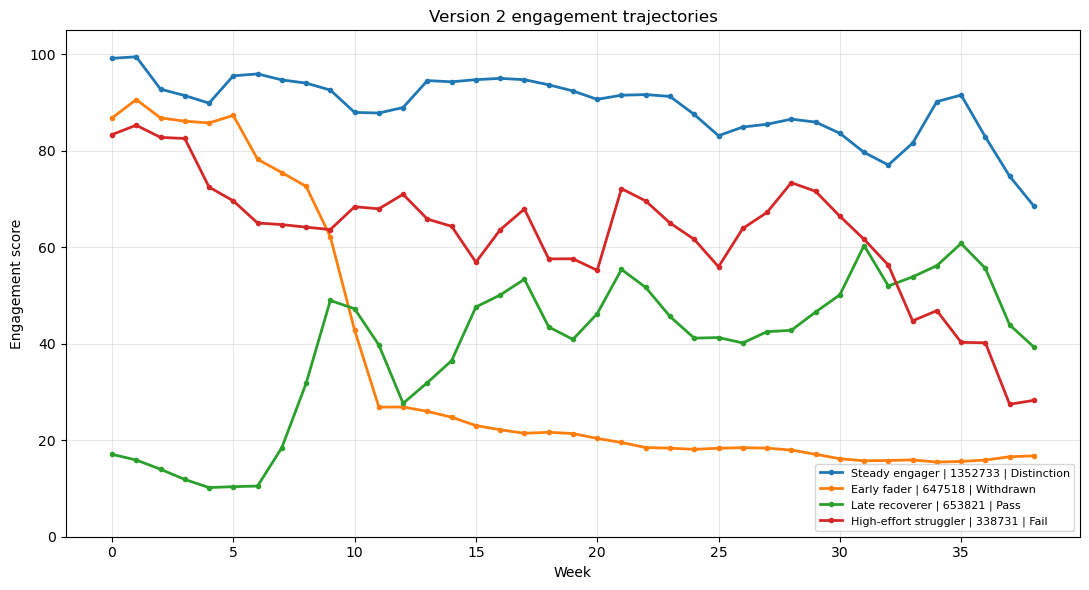


Students used for clean clustering: 2137 out of 2498
Excluded from clustering only: 361 near-non-starters

Clean 4 cluster profiles:
   cluster  n_students  mean_score  early_score  late_score  score_change  \
0        0         565       21.03        36.66       14.22        -22.44   
1        1         619       65.02        71.80       53.56        -18.24   
2        2         404       35.52        61.58       19.92        -41.67   
3        3         549       47.93        48.72       42.69         -6.03   

   volatility  zero_click_share  spike_ratio  slope  Distinction   Fail  \
0       11.75              0.86        16.44  -0.62        0.000  0.242   
1       16.06              0.13         5.54  -0.40        0.342  0.100   
2       19.40              0.65        11.50  -1.22        0.012  0.218   
3       16.24              0.36         8.54  -0.08        0.162  0.184   

    Pass  Withdrawn                       cluster_name  
0  0.011      0.747  Low intermittent at-risk l

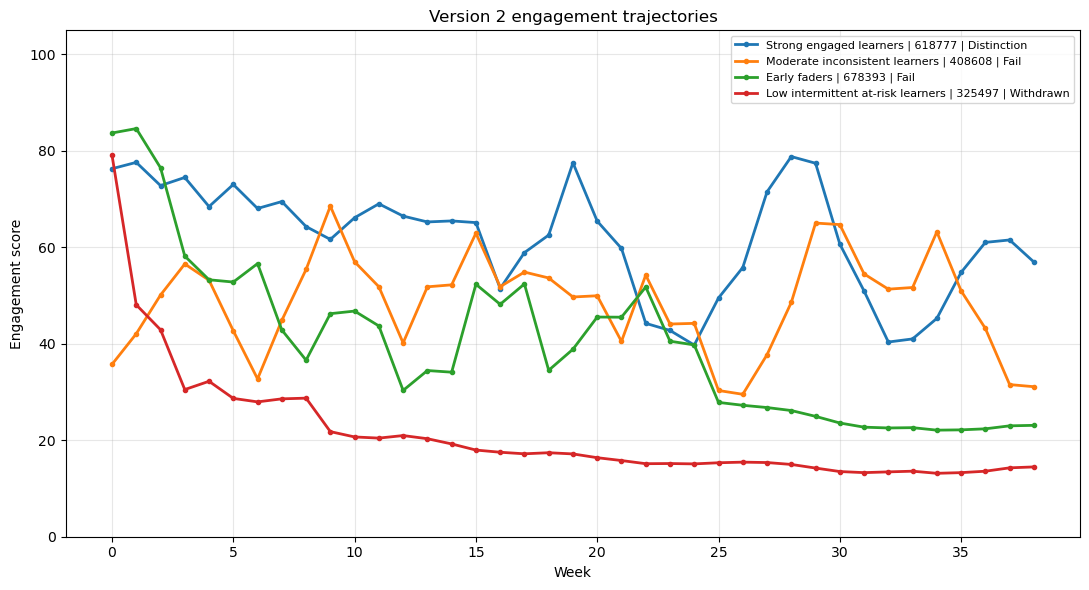


Done. Use these files first:
1. validation_v2_clean4.csv
2. validation_baseline_linear_clean4.csv
3. archetype_trajectories_v2_clean4.png
4. cluster_profiles_v2_clean4.csv
5. cluster_trajectories_v2_clean4.png


In [3]:
main()


## Upload back these outputs

Outputs are saved in this folder: validation CSVs, trajectory summary, archetype plot, and cluster profiles.